In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
import rfitools
import numba as nb
import importlib
importlib.reload(rfitools)
import time

In [2]:
with np.load('/home/mohanagr/Jupyter/MARS Fringe analysis (Summer 2025)/vis_dump.npz') as f:
    vis=f['vis']
    cnt=f['cnt']
    tstart=f['tstart']
    deltat=f['deltat']
    deltaf=f['deltaf']

In [3]:
vis.nbytes/1e3

688.8

In [4]:
deltat, deltaf

(array(1.07374182), array(4768.37158203))

In [5]:
fstart = 360*250e6/4096

In [6]:
fstart

21972656.25

In [7]:
vis.shape, vis.flags

((10, 410, 21),
   C_CONTIGUOUS : True
   F_CONTIGUOUS : False
   OWNDATA : True
   WRITEABLE : True
   ALIGNED : True
   WRITEBACKIFCOPY : False)

In [8]:
nant=7
triu_idx=np.triu_indices(nant,k=1) #upper triangle except main diag
nbl = len(triu_idx[0])
print(nbl, triu_idx)

21 (array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 5]), array([1, 2, 3, 4, 5, 6, 2, 3, 4, 5, 6, 3, 4, 5, 6, 4, 5, 6, 5, 6, 6]))


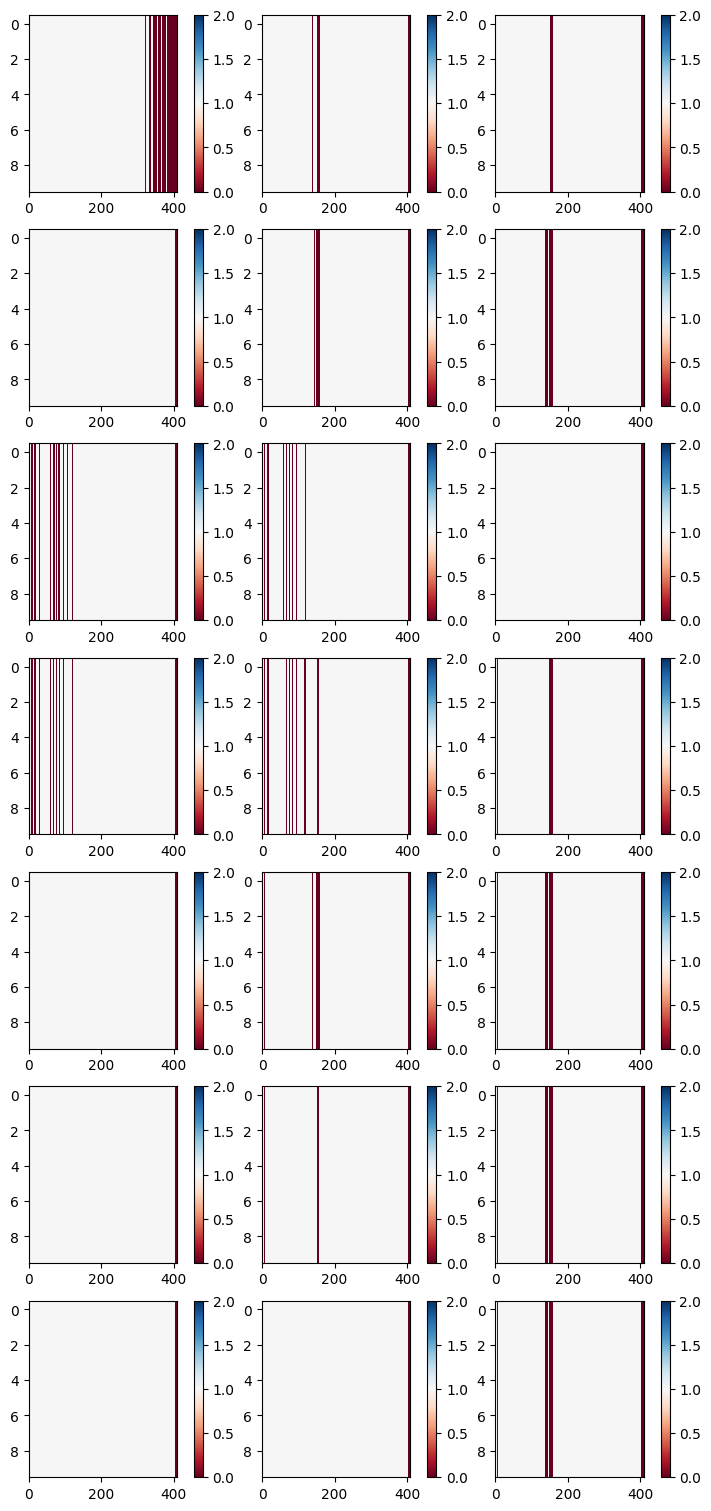

In [9]:
fig,ax = plt.subplots(7,3, layout='constrained')
fig.set_size_inches(7,15)
ax=np.ravel(ax)
pnum=0
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    # ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} bl_id={(i)}")
    # img=ax[pnum].imshow(np.angle(vis[:,:,i]),aspect='auto',cmap='RdBu',interpolation='none')
    img=ax[pnum].imshow(cnt[:,:,i]>0,aspect='auto',cmap='RdBu',interpolation='none',vmin=0, vmax=2)
    cbar=plt.colorbar(img,ax=ax[pnum])
    # ax[pnum].set_ylim(600,800)
    # ax[pnum].set_ylim(2000,4000)
    pnum+=1

Steps:
1. Generate delays for all pixels for all antenna

In [10]:
vis_avg = np.mean(vis,axis=0)
cnt_avg = np.sum(cnt,axis=0)
print(vis_avg.shape)

(410, 21)


In [11]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [12]:
NSIDE=256
t_idx = 0
NPIX=hp.nside2npix(NSIDE)
print("resol", hp.nside2resol(NSIDE,arcmin=True), "npix", NPIX)
co_dec,ra=hp.pix2ang(NSIDE,np.arange(NPIX))
dec=np.pi/2-co_dec

# obstime=Time(tstart+vis.shape[0] * deltat/2,format="unix",scale="utc")
obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
print(obstime)
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
altaz =src.transform_to(AltAz(location=ant0,obstime=obstime))

resol 13.741945647269624 npix 786432
1753264834.1802247


In [13]:
@nb.njit(parallel=True)
def geo_delay(bls,alt,az):
    npix = alt.shape[0]
    nbl = bls.shape[0] #each row is x, y, z
    delays = np.empty((nbl,npix),dtype='float64')
    c=299792458
    for pix in nb.prange(npix):
        cos_alt = np.cos(np.pi * alt[pix] / 180)
        sin_alt = np.sin(np.pi * alt[pix] / 180)
        cos_az = np.cos(np.pi * az[pix] / 180)
        sin_az = np.sin(np.pi * az[pix] / 180)
        for bl in range(nbl):
            ea,no,up = bls[bl]
            p = 0
            p += sin_az*cos_alt * ea #east
            p += cos_az*cos_alt * no #north
            p += sin_alt * up #up
            delays[bl, pix] = p/c
    return delays

In [14]:
bl_enus = rfitools.get_all_bls(coords,np.arange(len(coords)))
# bl_enus1 =  rfitools.get_all_bls(coords,np.arange(len(coords)), refonly=True)

(21, 3)


In [15]:
delays = geo_delay(bl_enus, altaz.alt.value, altaz.az.value)

In [16]:
#playing with generating per baseline delays from per antenna delays
idx=0
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(np.max(np.abs(delays[i] - (delays1[aj]-delays1[ai]))))

NameError: name 'delays1' is not defined

In [ ]:
#for one pixel
dd = delays1[:,0]
delays[:,0] - (dd[triu_idx[1]]-dd[triu_idx[0]]) # a numpy trick to generate per baseline delays

NameError: name 'delays1' is not defined

In [17]:
#baseline lengths
bl_lengths = np.sqrt(np.sum(bl_enus*bl_enus,axis=1))
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(antmap[ai], antmap[aj], i,ai,aj, bl_lengths[i])

MARS1 MARS2 0 0 1 174.45456775051662
MARS1 MARS4 1 0 2 6089.384461074008
MARS1 MARS5 2 0 3 2055.7884567985097
MARS1 MARS6 3 0 4 2248.2290395629816
MARS1 MARS7 4 0 5 1614.993536696582
MARS1 MARS8 5 0 6 3143.2792581319386
MARS2 MARS4 6 1 2 6240.3838025376035
MARS2 MARS5 7 1 3 1881.5962163339905
MARS2 MARS6 8 1 4 2309.689734452764
MARS2 MARS7 9 1 5 1458.5268016563846
MARS2 MARS8 10 1 6 3088.474324240012
MARS4 MARS5 11 2 3 7956.833009844907
MARS4 MARS6 12 2 4 4633.21326925574
MARS4 MARS7 13 2 5 7133.9978322114575
MARS4 MARS8 14 2 6 8741.141688683856
MARS5 MARS6 15 3 4 3541.1607982782593
MARS5 MARS7 16 3 5 953.4344496617705
MARS5 MARS8 17 3 6 3047.6686048967063
MARS6 MARS7 18 4 5 2623.064250068337
MARS6 MARS8 19 4 6 5391.147752404277
MARS7 MARS8 20 5 6 3655.4414760084646


In [18]:
fringes = np.exp(2j*np.pi*21e6*delays)

In [19]:
# good_bls = [2,3,4,7,8,9,10,16,17,18]
# good_bls = [5,10,17,19,20]
good_bls = np.arange(1,nbl)
print(good_bls)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [20]:
cnt[t_idx, :, 1:].shape

(410, 20)

In [21]:
good_freq_idx = np.bitwise_and.reduce(cnt[t_idx,:,good_bls]>0, axis=1) #across all baselines, excluding MARS1-2 because we wont use it
print(good_freq_idx.shape)

(20,)


In [22]:
good_freq_idx = np.bitwise_and.reduce(cnt_avg[:,good_bls]>10, axis=1)

334


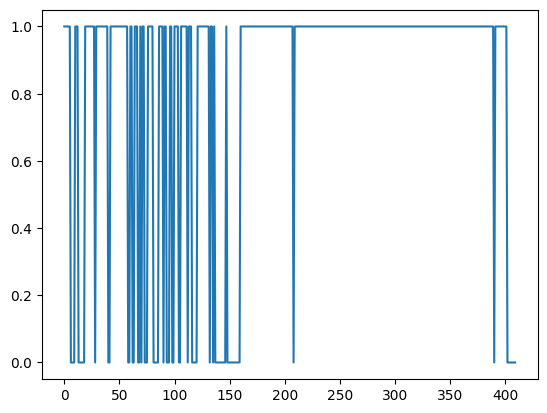

In [23]:
plt.plot(good_freq_idx)
print(np.sum(good_freq_idx))

In [24]:
freqs = np.arange(vis.shape[1]) * deltaf + fstart #Hz
good_freqs = freqs[good_freq_idx].copy()
print(len(good_freqs))

334


In [25]:
good_bls

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [26]:
delaysT = delays[good_bls,:].T.copy() #exclude MARS1-2
data = vis_avg[:, good_bls][good_freq_idx, :].copy() #exclude MARS1-2

In [27]:
data.shape, delaysT.shape

((334, 20), (786432, 20))

In [28]:
good_freqs.shape

(334,)

In [29]:
# @nb.njit(parallel=True)
# def get_map(data,freqs,delays,npix):
#     print(data.shape, freqs.shape, delays.shape)
#     map1 = np.zeros(npix, dtype=np.complex128)
#     nfreq, nbl = data.shape
#     N_vis = nfreq * nbl
#     for p in nb.prange(npix):
#         pixel_sum = 0j
#         for f in range(nfreq):
#             nu = freqs[f]
#             for b in range(nbl):
#                 tau = delays[p, b] #delay shape is npix, nbl for CPU

#                 # Calculate the fringe factor for this specific visibility
#                 fringe = np.exp(2j * np.pi * nu * tau)
                
#                 # Accumulate the dot product
#                 pixel_sum += fringe * data[f, b]
        
#         # Calculate the mean and assign to the pixel map
#         map1[p] = pixel_sum / N_vis
#     return map1

@nb.njit(parallel=True)
def get_map(data,freqs,delays,npix):
    print(data.shape, freqs.shape, delays.shape)
    map1 = np.zeros(npix, dtype=np.float64)
    nfreq, nbl = data.shape
    N_vis = nfreq * nbl
    for p in nb.prange(npix):
        pixel_sum = 0.
        for f in range(nfreq):
            nu = freqs[f]
            for b in range(nbl):
                tau = delays[p, b] #delay shape is npix, nbl for CPU

                # Calculate the fringe factor for this specific visibility
                fringe = np.exp(2j * np.pi * nu * tau)
                
                # Accumulate the dot product
                pixel_sum += fringe.real * data[f, b].real - fringe.imag * data[f, b].imag
        
        # Calculate the mean and assign to the pixel map
        map1[p] = pixel_sum / N_vis
    return map1

In [30]:
NPIX

786432

In [31]:
_ = get_map(data,good_freqs,delaysT,100)

(334, 20) (334,) (786432, 20)


In [32]:
t1=time.time()
map1 = get_map(data,good_freqs,delaysT,NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (786432, 20)
20.017183780670166


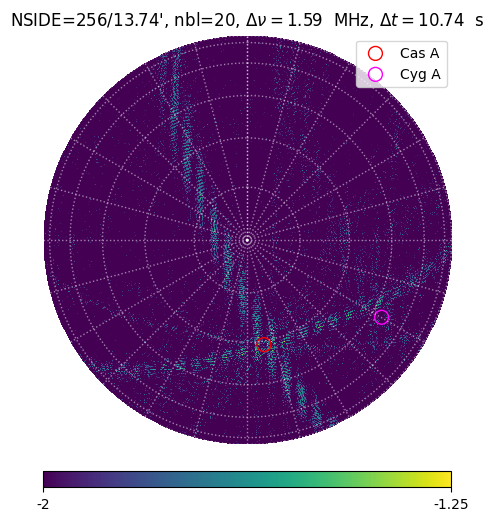

In [33]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

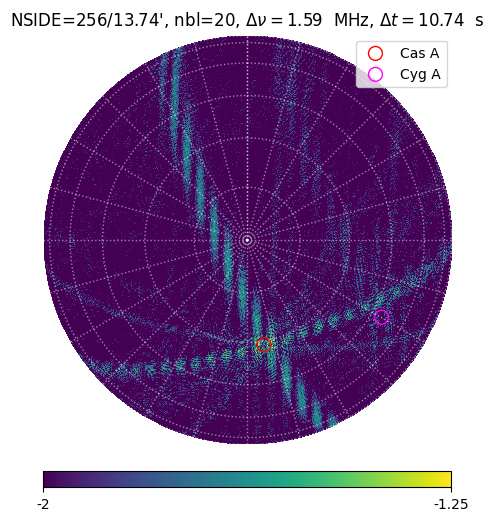

In [36]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

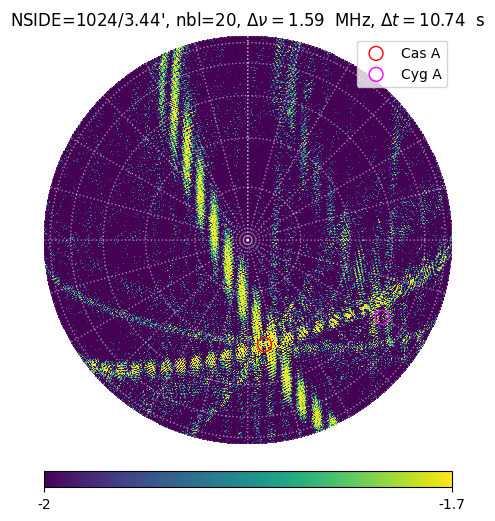

In [235]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(0,90),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

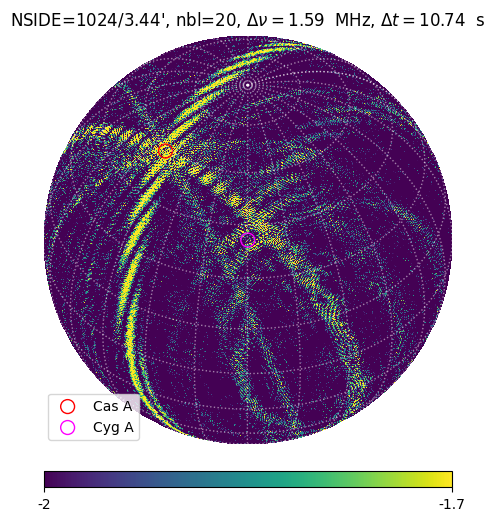

In [236]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(cyg_a.ra.deg,cyg_a.dec.deg),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')


hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

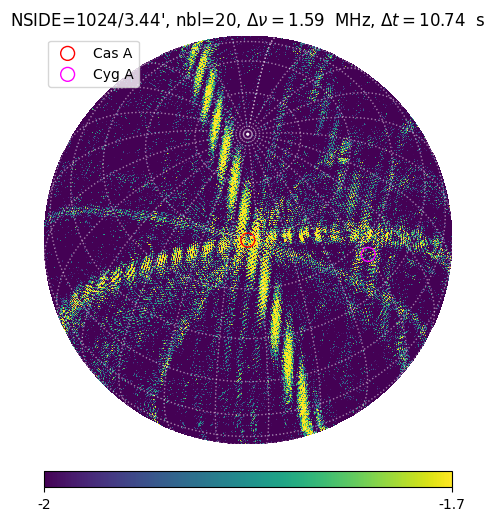

In [237]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(cas_a.ra.deg,cas_a.dec.deg),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')


hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()